In [ ]:
!apt-get update
!apt-get install -y libopencv-dev build-essential cmake

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64  InRelease [1,578 B]
Get:3 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Hit:4 http://archive.ubuntu.com/ubuntu noble InRelease
Get:5 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Get:6 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ InRelease [3,631 B]
Get:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu noble InRelease [17.8 kB]
Hit:8 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu noble InRelease
Get:9 https://cli.github.com/packages stable/main amd64 Packages [359 B]
Get:10 http://archive.ubuntu.com/ubuntu noble-backports InRelease [126 kB]
Get:11 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64  Packages [1,877 kB]
Get:12 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ Packages [73.2 kB]
Get:13 https://ppa.launchpadcontent.net/d

In [ ]:
%%writefile main.cpp
#include <iostream>
#include <opencv2/opencv.hpp>
#include <cuda_runtime.h>

int main() {
    std::cout << "--- Sistem Bilgileri ---" << std::endl;
    std::cout << "OpenCV Versiyonu: " << CV_VERSION << std::endl;

    int deviceCount = 0;
    cudaError_t error = cudaGetDeviceCount(&deviceCount);

    if (error == cudaSuccess && deviceCount > 0) {
        std::cout << "CUDA Durumu: Başarılı! Colab GPU Algılandı." << std::endl;
        std::cout << "Algılanan GPU Sayısı: " << deviceCount << std::endl;
    } else {
        std::cout << "CUDA Durumu: Cihaz bulunamadı veya GPU aktif değil!" << std::endl;
    }

    return 0;
}

Overwriting main.cpp


In [ ]:
!g++ main.cpp -o app `pkg-config --cflags --libs opencv4` -I/usr/local/cuda/include -L/usr/local/cuda/lib64 -lcudart
!./app

--- Sistem Bilgileri ---
OpenCV Versiyonu: 4.6.0
CUDA Durumu: Başarılı! Colab GPU Algılandı.
Algılanan GPU Sayısı: 1


In [19]:
import cv2
import numpy as np

# Create a dummy image if image1.jpg doesn't exist
try:
    img = cv2.imread('image1.jpg')
    if img is None:
        # Create a simple 300x300 grayscale image with varying pixel values
        img = np.zeros((300, 300), dtype=np.uint8)
        for i in range(300):
            img[i, :] = int(i / 300 * 255)
        cv2.imwrite('image1.jpg', img)
        print("Created dummy image1.jpg for demonstration.")
    else:
        print("image1.jpg already exists.")
except Exception as e:
    print(f"Error checking/creating image1.jpg: {e}")

Created dummy image1.jpg for demonstration.


In [20]:
%%writefile main.cpp
#include <iostream>
#include <opencv2/opencv.hpp>
#include <cuda_runtime.h> // For CUDA check

int main() {
    std::cout << "OpenCV Versiyonu: " << CV_VERSION << std::endl;

    // Colab GPU Bağlantı Kontrolü
    int deviceCount = 0;
    cudaError_t error = cudaGetDeviceCount(&deviceCount);

    if (error == cudaSuccess && deviceCount > 0) {
        std::cout << "Başarılı! Colab GPU (CUDA) Algılandı. Cihaz Sayısı: " << deviceCount << std::endl;
    } else {
        std::cout << "CUDA Cihazı Bulunamadı veya GPU Aktif Edilmedi!" << std::endl;
    }

    // Load the image
    cv::Mat image = cv::imread("image1.jpg");

    if (image.empty()) {
        std::cerr << "Error: Could not open or find the image. Make sure 'image1.jpg' exists." << std::endl;
        return -1;
    }

    // Create a new image for the processed result
    cv::Mat processed_image = cv::Mat::zeros(image.size(), image.type());

    // Process each pixel: multiply by 0.75 and add 20
    for (int y = 0; y < image.rows; ++y) {
        for (int x = 0; x < image.cols; ++x) {
            // For BGR images (3 channels)
            if (image.channels() == 3) {
                for (int c = 0; c < 3; ++c) {
                    processed_image.at<cv::Vec3b>(y, x)[c] = cv::saturate_cast<uchar>(image.at<cv::Vec3b>(y, x)[c] * 0.75 + 20);
                }
            }
            // For grayscale images (1 channel)
            else if (image.channels() == 1) {
                processed_image.at<uchar>(y, x) = cv::saturate_cast<uchar>(image.at<uchar>(y, x) * 0.75 + 20);
            }
        }
    }

    // Save the processed image
    if (!cv::imwrite("processed_image.jpg", processed_image)) {
        std::cerr << "Error: Could not save the processed image." << std::endl;
        return -1;
    }

    std::cout << "Image processing complete. 'processed_image.jpg' saved." << std::endl;

    return 0;
}

Overwriting main.cpp


In [21]:
!g++ main.cpp -o app $(pkg-config --cflags --libs opencv4) -I/usr/local/cuda/include -L/usr/local/cuda/lib64 -lcudart
!./app

OpenCV Versiyonu: 4.6.0
Başarılı! Colab GPU (CUDA) Algılandı. Cihaz Sayısı: 1
Image processing complete. 'processed_image.jpg' saved.


Original Image:


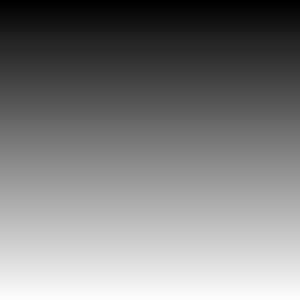


Processed Image:


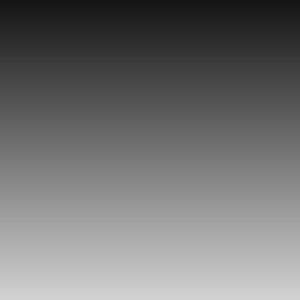

In [22]:
import cv2
from google.colab.patches import cv2_imshow

# Load the original and processed images
original_img = cv2.imread('image1.jpg')
processed_img = cv2.imread('processed_image.jpg')

if original_img is not None and processed_img is not None:
    print('Original Image:')
    cv2_imshow(original_img)
    print('\nProcessed Image:')
    cv2_imshow(processed_img)
else:
    print("Error: Could not load one or both images. Make sure 'image1.jpg' and 'processed_image.jpg' exist.")